<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Optimization with Graphics Processing Units <a class="tocSkip">

This notebook presents **GPU parallelization**, a coding framework/paradigm that can be used to dramatically speed up scientific computations.
Using Graphics Processing Units (GPUs) requires a different way of thinking with respect to programming.
An analogy could be the different perspective between sequential and object-oriented programming.
In this case, we need to think ''in parallel''.
In this notebook, we will discuss:

- How to identify repeated and independent actions performed by some piece of code
- The important role of memory access in highly parallelizable code
- A simple example of calculating a function (the $\chi^2$) on a grid using brute force
- How brute force with GPUs can be combined with more sophisticated algorithms like MCMC, and how it can fit within a Bayesian framework.

# Setup

In [1]:
### 20/06/2025: Currently, there is a mismatch between the GPU driver and compiler on Colab.
### This causes a critical error and the GPU code cannot be compiled and executed.
### Running the following cells is required for successful execution on Colab.
### Maybe at a later date this problem will be fixed.
### This also depends on the type of GPU (currently T4), so, in general, be careful when setting up the environment to run this notebook.

# If the CUDA version from these two commands is not the same, then run the next cell
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Thu Jul 30 12:20:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8       

In [2]:
# This install the entire CUDA (toolkit and driver) and takes some time
!apt-get -qq update -y
!apt-get -qq install -y cuda-12-4

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Preconfiguring packages ...
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../systemd-sysv_249.11-0ubuntu3.21_amd64.deb ...
Unpacking systemd-sysv (249.11-0ubuntu3.21) over (249.11-0ubuntu3.20) ...
Preparing to unpack .../libpam-systemd_249.11-0ubuntu3.21_amd64.deb ...
Unpacking libpam-systemd:amd64 (249.11-0ubuntu3.21) over (249.11-0ubuntu3.20) ...
Preparing to unpack .../systemd_249.11-0ubuntu3.21_amd64.deb ...
Unpacking systemd (249.11-0ubuntu3.21) over (249.11-0ubuntu3.20) ...
Preparing to unpack .../libsystemd0_249.11-0ubuntu3.21_amd64.deb ...
Unpacking libsystemd0:amd64 (249.11-0ubuntu3.21) over (249.11-0ubuntu3.20) ...
Setting up libsystemd0:amd64 (249.11-0ubuntu3.21) ...
Selecting previously unselected pac

In [3]:
# Resetting some environment variables
!sudo rm -rf /usr/local/cuda
!sudo ln -s /usr/local/cuda-12.4 /usr/local/cuda

!export PATH=/usr/local/cuda-12.4/bin:$PATH
!export LD_LIBRARY_PATH=/usr/local/cuda-12.4/lib64:$LD_LIBRARY_PATH

In [4]:
# If the CUDA version for both compiler and driver is the same, then you are good to go!
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Mar_28_02:18:24_PDT_2024
Cuda compilation tools, release 12.4, V12.4.131
Build cuda_12.4.r12.4/compiler.34097967_0
Thu Jul 30 12:32:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8      

In [5]:
import numpy as np
import pandas as pd
import time
import requests
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Repository:
https://github.com/AstroStat-Academy/astrostat-school-7.git

Branch:
main

Working in:
/content/astrostat-school-7/GPU_Parallelization

Content:
	 ['GPU_parallelization.ipynb', 'images']
Imported matplotlib.
Imported seaborn.
Plotting style set.


# Excitement vs Routine

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/rome_to_vatican.png?raw=1" width="48%" style="display:inline-block;">
<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/new_york.png?raw=1" width="48%" style="display:inline-block;">

<table><tr><td width=80%><center><br>
    Figure 1. Excitement vs routine. <i>Left -</i> The route from the venue of the school in Rome to Vatican City. <i>Right -</i> The *same* route in New York. Both routes are roughly the same distance in a straight line.
<br></center></td></tr></table>

*"I say unto you: one must still have chaos in oneself to be able to give birth to a dancing star. I say unto you: you still have chaos in yourselves."*

F. Nietzsche, 'Thus spoke Zarathustra'

# Introduction

Graphics Processing Units (GPUs) are massively parallel hardware devices, historically used for rendering graphics. These devices are capable of perfoming an incredible amount of computations in real time, leading to the realistic graphics we routinely see in video games nowadays. However, the same computational power can be harnessed to perform scientific computations. This has led, somewhat ironically, to the development of powerful GPUs without a port to connect a monitor to.

Some "traditional" GPU jargon: shaders, textures, device memory, etc.

At some point, somebody realized that these devices could be used just for computations - let there be GPGPU and CUDA.



<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/geforce256.webp?raw=1" width="48%" style="display:inline-block;">
<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/nvidia-l4-qtr-left.jpeg?raw=1" width="48%" style="display:inline-block;">

<table><tr><td width=600><center><br>
    Figure 2. <i>Left -</i> A GPU from 1999 - notice the gaming roots (<a href="https://9gag.com/gag/av8jBpW?utm_source=copy_link&utm_medium=post_share" target="_blank">original image</a>). <i> Right -</i> One of the latest General Purpose GPUs (an Nvidia L4 Tensor Core). Notice the lack of a monitor port.
<br></center></td></tr></table>

The highly parallel power of GPUs is ''raw'', which means that the tremendous speed up they can offer will not necessarily occur for any type of computations. A necessary ''code analysis'' step needs to be taken first. Specifically, quoting from [Barsdell et al. (2010)](https://ui.adsabs.harvard.edu/abs/2010MNRAS.408.1936B/abstract):

> <i>Algorithms with well-defined memory access patterns and high arithmetic intensity stand to receive the greatest performance boost from massively parallel architectures.</i>

In simpler words, if your code needs to do the same ''dumb'', mundane, repetitive task multiple times (the more the better), then GPUs could be very helpful. In contrast, quoting from the same paper:

> <i> [Algorithms] that involve a significant amount of decision-making may struggle to take advantage of the available processing power.</i>

## Have you heard of "vectorization"?

You might have heard of this term when working with some python libraries. Let's assume we want to multiply each number in an array with a fixed number (this could be a different simple algebraic operation, like dividing, adding, subtracting, taking the square or some other power, a sine or cosine, etc). Vectorization consists in re-coding the loop operations in such a way as to process the element-wise operations faster. This does not necessarily mean running the code in parallel, but is towards this direction: **writing your code in a specific way can lead to faster execution**.

The simplest (sequential) programming way to achieve the result of the example above would be by writing a loop that goes over each element in the array and performs the required operation. However, this type of algorithm is a good candidate for parallel execution. For example, if the array is of size 500, we could use 5 CPU threads working at the same time, each processing 100 elements, with the total computation being roughly 5 times faster. Obviously, the more threads available the faster the computation. For example, if there is one thread available per array element we could speed this up by a factor of 500.

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/np-vectorize-thumbnail.png?raw=1" width="400" style="display:block; margin-left:auto; margin-right:auto;"/>

<table><tr><td width=600><center><br>
        Figure 3. Example of a *vectorized* function in python: the element-wise sum of two arrays. Each summation can happen independently of and in parallel to the others.
<br></center></td></tr></table>
        


## Examples of good GPU use cases

Here is a tentative list of problems/algorithms that are efficiently (sometimes ridiculously) parallelizable:
* **N-body calculations:** In an ensemble of particles, the force of gravity between any pair of particles is independent from any other particle (Newton's law):
$$ \Large F_{ij} = G \frac{M_i M_j}{r_{ij}} $$
<br><br>

* **Ray shooting:** in gravitational (micro)lensing, each ray deflection by a lens is independent of all other rays and lenses.

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/schematic.png?raw=1" width="400" style="display:block; margin-left:auto; margin-right:auto;"/>

<table><tr><td width=700><center><br>
Figure 4. Illustration of the ray-shooting technique used in gravitational lensing (and elsewhere). Each ray deflection by a microlens is independent of all the other rays and microlenses. Taken from <a href="https://ui.adsabs.harvard.edu/abs/2014A%26C.....6....1V/abstract">Vernardos & Fluke (2014)</a>.
<br></center></td></tr></table>

* **Neural networks:** see perceptron, or fully-connected layers:
$$ \Large \hat{y} = f\left( \sum \mathbf{w} \cdot \mathbf{x} + b \right)$$
<br><br>

* **Convolutions** are ridiculously parallelizable (either directly or through FFT transforms)
<br><br>

On the other hand, a bad/not optimal GPU algorithm would be one that requires constant communication between threads/kernels, or does not have a well-defined memory access pattern - see figure below. We will see this in more detail.


<table>
    <tr>
        <td>
            Good memory access pattern:            
        </td>
        <td width=700>
            <img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/good_memory_access.png?raw=1" alt="drawing" width="800"/>
        </td>
    </tr>
</table>
<table>
    <tr>
        <td>
           Bad memory access pattern:            
        </td>
        <td width=700>
            <img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/bad_memory_access.png?raw=1" alt="drawing" width="800"/>
        </td>
    </tr>
</table>

# How do GPU codes work?


## Managing memory

The last point raises an important question related to GPUs: *memory management*. Let us imagine the following example of calculating the mean of 1,000,000 values. We can break the problem into these steps:

1. Define 1,000 threads that will work in parallel each tasked with adding 1,000 numbers (in a loop).
2. Wait for all partial sums to be computed.
3. Add the computed 1,000 partial sums in a loop to obtain the final sum.
4. Divide by 1,000,000 to get the mean (this can also happen in each thread to avoid very large numbers).

**Using parallel CPUs**: Imagine that we want to distribute this task to 1,000 CPUs, most likely available in several computing nodes of a computing cluster. To make things a bit more clear, let's assume 50 nodes of 20 CPUs each. Each CPU will run one loop and provide a partial sum, but in order to do so **it must have access to the particular chunk of 1,000 numbers it needs to add**. Because our CPUs are physically located across different machines, we need to divide the inital 1,000,000 numbers into chunks of memory, each containing a set of 1,000 numbers, and transfer them to each node accordingly. The first 20 chunks will go to the first node, the next 20 to the second, etc. Once each CPU completes their task of calculating a partial sum, which is just a number, the resulting 1,000 partial sums will need to be gathered to a single node for a CPU to take over the task of summing them up. This is how MPI works.


**Using a GPU**: GPUs are separate hardware devices (think of them as a computing node within your computer) that have mutliple threads available, usually thousands. The GPU threads have some limitations compared to CPUs, but let's not digress here, just remember that they are a bit 'dummer' and can handle simpler tasks. GPUs have their own memory independently from the RAM of the computer, just as a separate node would have. Hence, similarly to the CPU case above, we need to transfer the 1,000,000 numbers to GPU memory and then transfer the final result back to the CPU so that we can further process it, save it, make a plot, etc. The important difference here is that all memory will be visible to all the GPU threads, therefore, we have to **instruct each thread which chunk of memory to work on**.

## Threads, Blocks, and memory access

Our basic "executable unit" is called a thread (similarly to a CPU thread), which runs instances of a GPU kernel - this is how we call the units of code (or functions) that are ran by the GPU.

Kernels are executed by 1D, 2D, or 3D grids of threads, and threads can be further organized into 1D, 2D, or 3D blocks.

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/GPU_memory.png?raw=1" width="1200" style="display:block; margin-left:auto; margin-right:auto;"/>

<table><tr><td width=600><center><br>
Figure 5. GPU memory types. Taken from <a href="https://www.researchgate.net/figure/Structure-of-GPU-memory_fig2_365898686">Eum et al. (2022)</a>.
<br></center></td></tr></table>

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">
    
**The most important challenge when writing GPU code**, is handling the memory access. This boils down to matching each thread (that is running within a block) to a specific memory location (either a single variable or a chunk of larger memory, e.g. a part of an array).

<!-- **Let's illustrate this with a few sketches!** -->
    
</div>

# Working example: a simple $\chi^2$

One such ''ridiculously parallelizable'' problem is the computation of a $\chi^2$ metric:

$$\Large \chi^2 = \sum_{i=0}^{N} \frac{(d_i - \mathcal{M}_i)^2}{\sigma_i^2}$$

where $d$ is a measurement, $\sigma$ its associated uncertainty, and $\mathcal{M}$ a model prediction. The index $i$ runs through a collection of such measurements that have a logical association, for example, a time-series or an image.

Below we show an example of fitting a straight line to some time-series/light curve data. The (linear) model is:

$$ \Large \mathcal{M}(t|\alpha,\beta) = \alpha t + \beta$$

where $\alpha$ and $\beta$ are the free parameters - in this case, the slope and intercept of a straight line. Given some values of the free parameters, we can calculate the $\chi^2$.

### First, we define the light curve data as a list of observations (time, flux, error)

In [10]:
measurements = np.array([
    [0.20, 12.3, 1.1],
    [0.41, 13.4, 0.7],
    [0.54, 13.2, 0.8],
    [0.72, 14.7, 1.2],
    [1.10, 15.8, 0.9],
    [1.24, 16.2, 0.7],
    [1.27, 17.3, 0.5],
    [1.35, 17.9, 0.6],
    [1.41, 18.5, 0.9],
    [1.89, 19.1, 1.1],
    [2.11, 20.3, 0.8],
    [2.13, 20.1, 0.6],
    [2.19, 21.4, 0.7],
    [2.39, 22.0, 0.7],
    [2.37, 22.5, 0.8]
],dtype=np.float64)
t = measurements[:,0] # time in units of years
f = measurements[:,1] # flux in arbitrary units
e = 1*measurements[:,2] # error in the same units as flux
N_data = len(f)
print("Length of data: ", N_data)

Length of data:  15


### Second, we define the model

In this case it is just a straight line with 2 free parameters, which we set to some initial values.
We evaluate the model at the (time) location of each data point.

In [77]:
def my_model(x,alpha,beta):
    y = alpha*x + beta
    return y

a = 4.36 # in units of flux/time
b = 11.47 # in units of flux
model = [ my_model(x,a,b) for x in t ]
print("Length of model: ", len(model))

Length of model:  15


### Third, we compare the model to the data by calculating the corresponding $\chi^2$

In [78]:
def chi2_cpu(d,e,m,N_data):
    chi2 = 0.0
    for i in range(0,N_data):
        chi2_term = (d[i]-m[i])/e[i]
        chi2 = chi2 + np.power(chi2_term,2)
    return chi2

chi2 = chi2_cpu(f,e,model,N_data)
print("The chi^2 value is: ",chi2)

The chi^2 value is:  6.785791308460567


### Finally, let's plot the data, our model, and its $\chi^2$ value

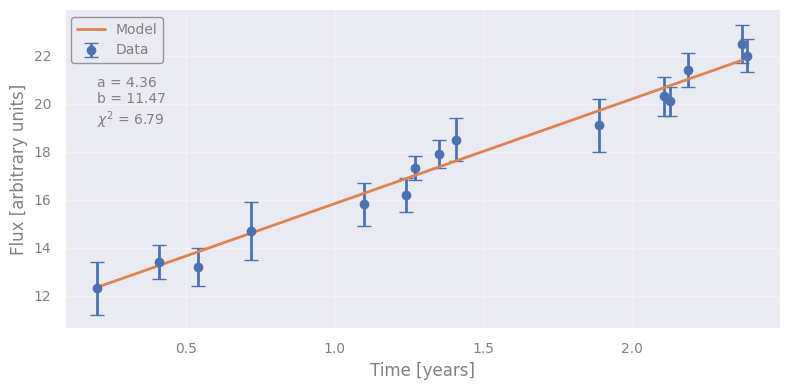

In [79]:
data_plot = plt.errorbar(t, f, yerr=e, fmt='o', capsize=5, label="Data")

tt = np.linspace(t[0],t[-1],50) # some t values on which to calculate the model, just for plotting purposes
model = [my_model(t,a,b) for t in tt]
model_plot = plt.plot(tt,model,label="Model")

# Cosmetics (labels, legend, etc)
my_text = f"a = {a:.2f} " + f"\nb = {b:.2f} " + "\n" + rf"$\chi^2$ = {chi2:.2f}"
plt.text(0.2,20, my_text, horizontalalignment='left', verticalalignment='center')
plt.legend()
plt.xlabel('Time [years]')
plt.ylabel('Flux [arbitrary units]')

plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 1: assign different model parameters by hand and try to minimize the $\chi^2$</b></font>

Lets see how close to the minimum you can get!

</div>

# Brute force parameter estimation - CPU vs GPU

How do we find the best-fit (lowest $\chi^2$) $a,b$ parameters?
Or how do we explore the entire $a,b$ parameter space and get confidence intervals on $a,b$?

Remember from lectures on Optimization and MCMC:

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/S.png?raw=1" width="48%" style="display:inline-block;">
<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/testfunc.png?raw=1" width="48%" style="display:inline-block;">

<table><tr><td width=600><center><br>
    Figure 6. Probability (likelihood or posterior) surfaces. These surfaces were used as examples in the lecture on Optimization (Left) and MCMC (Right).
<br></center></td></tr></table>

### Let's define a plotting function for convenience.
We plot the $\chi^2$ and likelihood surfaces as a function of $a,b$.


In [114]:
def plot_likelihood_surf(x,y,z,z_like):

    fig, axs = plt.subplots(1,2)
    #fig.set_figheight(9)
    fig.set_figwidth(15)

    #im = axs[0].pcolor(a_grid,b_grid,chi2_surf,cmap='viridis')
    im = axs[0].contour(x,y,z,levels=[2,5,10,20,50,100,200,400,800],cmap="viridis")
    fig.colorbar(im,ax=axs[0],label=r'$\chi^2$')
    axs[0].set_ylabel('b - intercept [flux]')
    axs[0].set_xlabel('a - slope [time/flux]')

    im = axs[1].pcolor(x,y,z_like,cmap='viridis')
    fig.colorbar(im,ax=axs[1],label=r'$e^{-\chi^2}$')
    axs[1].set_ylabel('b - intercept [flux]')
    axs[1].set_xlabel('a - slope [time/flux]')

    plt.show()

### Let's define a convenient function that calculates the $\chi^2$ on the CPU (3 nested loops).

We can easily revisit this function and implement a different model.

In [115]:
def CPU_full_chi2(a_grid,b_grid,N_a,N_b,t,f,e,N_data):
    chi2_surf = np.empty([N_a,N_b])
    like_surf = np.empty([N_a,N_b])
    for i in range(0,len(a_grid)):
        for j in range(0,len(b_grid)):
            #model = [ my_model(x,a_grid[i],b_grid[j]) for x in t ]
            #chi2_tmp = chi2_cpu(f,e,model,N_data)

            chi2 = 0.0
            for k in range(0,N_data):
                my_model = a_grid[i]*t[k] + b_grid[j]
                chi2_term = (f[k]-my_model)/e[k]
                chi2 = chi2 + np.power(chi2_term,2)

            like = np.exp(-chi2)

            chi2_surf[i][j] = chi2
            like_surf[i][j] = like

    return chi2_surf,like_surf

### Let's define the GPU kernel that calculates $\chi^2$ and a convenient function that transfers memory to and from the GPU.

We will examine this code in detail.

In [116]:
import os

### These two lines are needed if you are running this notebook locally on your laptop.
#os.environ['NUMBAPRO_LIBDEVICE'] = "/anaconda3/pkgs/cuda-nvcc-12.3.52-0/nvvm/libdevice"
#os.environ['NUMBAPRO_NVVM'] = "/anaconda3/pkgs/cuda-nvcc-12.3.52-0/nvvm/lib64/libnvvm.so"

import math
import numpy as np
from numba import cuda,float64


@cuda.jit
def chi2_kernel(d_a, d_b, d_t, d_f, d_e, N_data, k_chi2, k_like):
    # Converting thread and block indices to input and output memory indices
    #id_x,id_y = cuda.grid(2)
    id_a = int(cuda.threadIdx.x)
    id_b = int(cuda.blockIdx.x)
    size = int(cuda.blockDim.x)
    id_out = id_a*size + id_b

    # Managing "small" memory
    k_t = cuda.shared.array(shape=(512),dtype=float64)
    k_f = cuda.shared.array(shape=(512),dtype=float64)
    k_e = cuda.shared.array(shape=(512),dtype=float64)
    if cuda.threadIdx.x < N_data:
        k_t[cuda.threadIdx.x] = d_t[cuda.threadIdx.x]
        k_f[cuda.threadIdx.x] = d_f[cuda.threadIdx.x]
        k_e[cuda.threadIdx.x] = d_e[cuda.threadIdx.x]
    cuda.syncthreads()

    # Getting parameter values
    a_val = d_a[id_a]
    b_val = d_b[id_b]

    # Calculating chi^2
    chi2_val = 0.0
    for i in range(0,N_data):
        model_val = a_val*k_t[i] + b_val
        chi2_term = (k_f[i]-model_val)/k_e[i]
        chi2_val = chi2_val + math.pow(chi2_term,2)

    # Storing chi^2
    k_chi2[id_out] = chi2_val
    k_like[id_out] = math.exp(-chi2_val)


def GPU_set_run_chi2(a_grid,b_grid,N_a,N_b,N_blocks,N_threads,t,f,e,N_data):
    # Move input data to the device
    d_a = cuda.to_device(a_grid) # global memory
    d_b = cuda.to_device(b_grid)
    d_t = cuda.to_device(np.ascontiguousarray(t,dtype=np.float64)) # local memory
    d_f = cuda.to_device(np.ascontiguousarray(f,dtype=np.float64))
    d_e = cuda.to_device(np.ascontiguousarray(e,dtype=np.float64))

    # Create output data on the device
    d_chi2 = cuda.device_array(N_a*N_b, dtype=np.float64, stream=None)
    d_like = cuda.device_array(N_a*N_b, dtype=np.float64, stream=None)

    # Launch the kernels
    chi2_kernel[N_blocks, N_threads](d_a,d_b,d_t,d_f,d_e,N_data,d_chi2,d_like)

    # Wait for all threads to complete
    cuda.synchronize()

    # Copy the output array back to the host system
    chi2_gpu = d_chi2.copy_to_host()
    chi2_surf_gpu = chi2_gpu.reshape(N_a,N_b)
    like_gpu = d_like.copy_to_host()
    like_surf_gpu = like_gpu.reshape(N_a,N_b)

    return chi2_surf_gpu,like_surf_gpu

### Let's define a grid of paramaters and start exploring

In [152]:
# We need to ensure that our ranges are broad enough.
min_a = -5
max_a = 15
N_a = 345 # number of grid points
a_grid = np.linspace(min_a,max_a,N_a)

min_b = -20
max_b = 40
N_b = 345 # number of grid points
b_grid = np.linspace(min_b,max_b,N_b)


# The following two variables correspond to the sizes of the a and b grids on the GPU, but this is purely due to the chosen algorithmic design.
# These should be set to "power of 2" values (128, 256, 512, etc).
blocks_per_grid = N_a
threads_per_block = N_b


print('Likelihood calculations on CPU: %d' % (N_a*N_b) )

print('Total number of GPU threads launched: %d' % (blocks_per_grid*threads_per_block) )

Likelihood calculations on CPU: 119025
Total number of GPU threads launched: 119025


### Calculating the $\chi^2$ on the CPU

CPU time:  8.149704694747925


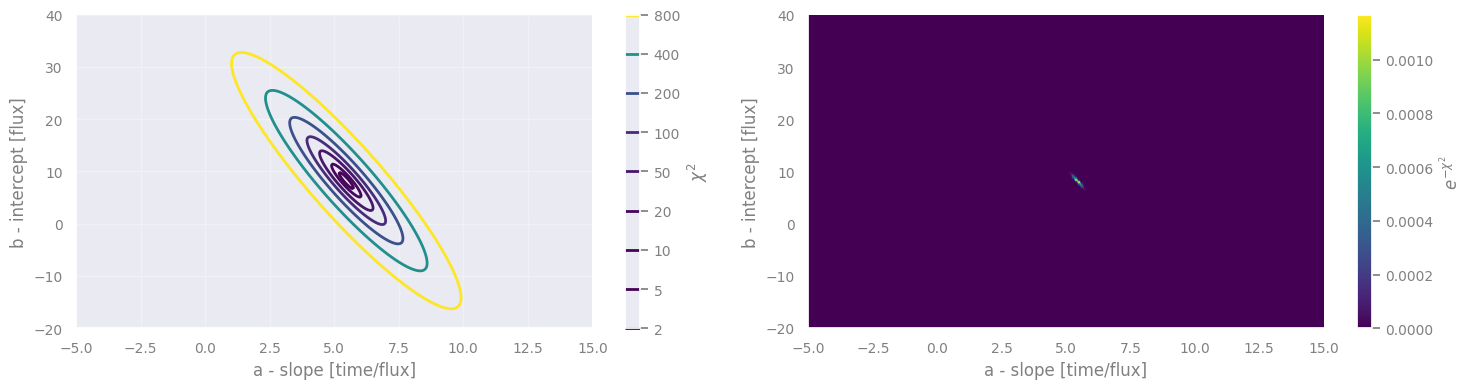

In [153]:
t0 = time.time()
chi2_surf,like_surf = CPU_full_chi2(a_grid,b_grid,N_a,N_b,t,f,e,N_data)
t1 = time.time()
cpu_time = t1-t0
print("CPU time: ", cpu_time)

plot_likelihood_surf(a_grid,b_grid,chi2_surf,like_surf)

### Calculating the $\chi^2$ on the GPU

GPU time:  0.009671211242675781
Speed up: 842.68


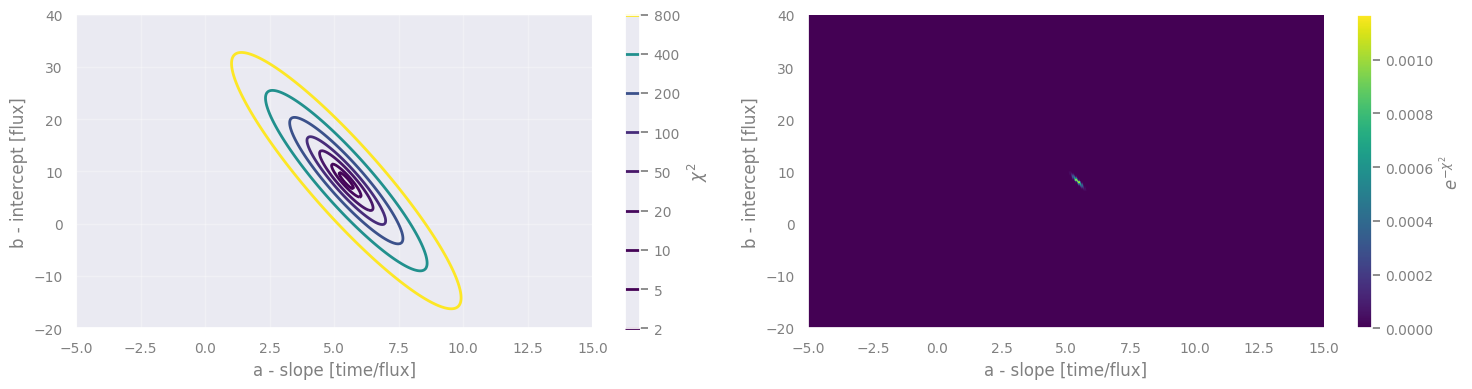

In [154]:
t0 = time.time()
chi2_surf_gpu,like_surf_gpu = GPU_set_run_chi2(a_grid,b_grid,N_a,N_b,blocks_per_grid,threads_per_block,t,f,e,N_data)
t1 = time.time()
gpu_time = t1-t0
print("GPU time: ",gpu_time)
speedup = float(cpu_time)/float(gpu_time)
print("Speed up: {speedup:.2f}".format(speedup=speedup))

plot_likelihood_surf(a_grid,b_grid,chi2_surf_gpu,like_surf_gpu)

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: what do you notice if you run the GPU code more than one time?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

The code runs even faster the second time! This is because Just-In-Time (JIT) compilation is used as opposed to a language like C++ or CUDA and even python code using GPUs. From wikipedia:
    
<i>A system implementing a JIT compiler typically continuously analyses the code being executed and identifies parts of the code where the speedup gained from compilation or recompilation would outweigh the overhead of compiling that code.</i>
</details>
</div>


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 2: repeat the above calculations by increasing the data error bars.</b></font>
    
For example, multiply the errors by by a factor of 2, 3, etc.

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 3: repeat the above calculations by increasing the number of grid points.</b></font>

Do this for both CPU and GPU. What happens if you try values that are not "powers of 2"?
    
</div>

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">
    
**The model does not have to be linear**. Any function can be evaluated inside the kernel.
    
</div>

# Combining GPU code with sophisticated algorithms

No matter what is your fancy sampler - MCMC, HMC, Nested sampling, gradient decent, etc - you will always need to evaluate the likelihood. The faster you can achieve this the better. But likelihood functions can be very costly to evaluate. For example, when there are **nuissance parameters** involved!

But specifically with respect to Bayesian methods (see also lecture on Bayesian Statistics, there is a very interesting situation:

$$ \Large P(\boldsymbol{\theta}| \boldsymbol{d}, I) = \frac{P(\boldsymbol{d}|\boldsymbol{\theta},I) \; P(\boldsymbol{\theta}|I) }{P(\boldsymbol{d}|I)} $$

where the likelihood can be written as the evidence of another "hidden" or "inner" Bayesian problem:

$$ \Large P(\boldsymbol{\eta}| \boldsymbol{d}, \boldsymbol{\theta},I) = \frac{P(\boldsymbol{d}|\boldsymbol{\eta},\boldsymbol{\theta},I) \; P(\boldsymbol{\eta}|\boldsymbol{\theta},I) }{P(\boldsymbol{d}|\boldsymbol{\theta},I)} $$  or

$$ \Large P(\boldsymbol{d}|\boldsymbol{\theta},I) = \int P(\boldsymbol{d}|\boldsymbol{\theta}, \boldsymbol{\eta}, I) \; P(\boldsymbol{\eta}|\boldsymbol{\theta},I) \; \mathrm{d}\boldsymbol{\eta} $$

### Example: A distant supernova explosion

Data - $\boldsymbol{d}$: a supernova light curve.

Model parameters of interest - $\boldsymbol{\eta}$: the supernova luminosity, for example. This is what we are after!

Nuissance parameters - $\boldsymbol{\nu}$: the location of the supernova within its host galaxy (unobservable). For example, the properties of the progenitor star depend on the local star formation history and Inter-Stellar Medium (ISM) composition.


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/supernovae.jpg?raw=1" width="64%" style="display:inline-block;">
<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/GPU_Parallelization/images/supernova_light_curve.jpg?raw=1" width="32%" style="display:inline-block;">

<table><tr><td width=700><center><br>
    Figure 7. <i>Left -</i> Some distant, barely resolved supernovae. <i>Right -</i> Light curve of SN 2017cfd from <a href="https://ui.adsabs.harvard.edu/abs/2020ApJ...892..142H/abstract" target="_blank">Han et al. 2020</a>.
<br></center></td></tr></table>


We can formulate this problem as:

$$ \Large P(\boldsymbol{\eta}| \boldsymbol{d}) = \frac{P(\boldsymbol{d}|\boldsymbol{\eta}) \; P(\boldsymbol{\eta}) }{P(\boldsymbol{d})} $$

where each value of the likelihood has been calculated for all the locations:

$$ \Large P(\boldsymbol{d}|\boldsymbol{\eta}) = \int P(\boldsymbol{d}|\boldsymbol{\eta},\boldsymbol{\nu}) \; P(\boldsymbol{\nu}|\boldsymbol{\eta}) \; \mathrm{d}\boldsymbol{\nu} $$

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:**  Come up with one such real world scenario and write down the main Bayes formula and the likelihood as the evidence of an "inner" problem.

</div>

In [ ]:
#EOF